# Explorative analysis of share-of-wallet data

This notebook compares category spending across seasons and years using the category-level and category-counterpart share-of-wallet datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## Load and clean the data

The category dataset is used for the main seasonal spending analysis. The category-counterpart dataset adds detail about which merchants drive spending within each category.

In [2]:
sow_category = pd.read_csv("../sow_category.csv")
sow_counterpart = pd.read_csv("../sow_category_counterpart.csv")

def clean_sow(dataframe):
    cleaned = dataframe.copy()
    cleaned["date"] = pd.to_datetime(
        cleaned["year_month"].astype(str),
        format="%m-%Y"
    )
    cleaned["year"] = cleaned["date"].dt.year
    cleaned["month"] = cleaned["date"].dt.month
    cleaned["category"] = (
        cleaned["category"]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace({
            "restaurant": "restaurants",
            "lebensmittel": "groceries",
            "fitness": "wellness",
            "hotel": "hotels"
        })
    )
    cleaned["season"] = cleaned["month"].map({
        12: "Winter", 1: "Winter", 2: "Winter",
        3: "Spring", 4: "Spring", 5: "Spring",
        6: "Summer", 7: "Summer", 8: "Summer",
        9: "Autumn", 10: "Autumn", 11: "Autumn"
    })
    cleaned["season"] = pd.Categorical(
        cleaned["season"],
        categories=["Winter", "Spring", "Summer", "Autumn"],
        ordered=True
    )
    return cleaned

sow_category = clean_sow(sow_category)
sow_counterpart = clean_sow(sow_counterpart)

# 2020 contains only one month, so exclude it from seasonal comparisons.
sow_category = sow_category[sow_category["year"] >= 2021].copy()
sow_counterpart = sow_counterpart[sow_counterpart["year"] >= 2021].copy()

print("Category rows:", len(sow_category))
print("Category-counterpart rows:", len(sow_counterpart))
print("Years included:", sorted(sow_category["year"].unique()))
print("Clean categories:", sorted(sow_category["category"].dropna().unique()))
display(sow_category.head())
display(sow_counterpart.head())

Category rows: 644
Category-counterpart rows: 4688
Years included: [np.int32(2021), np.int32(2022), np.int32(2023)]
Clean categories: ['cash', 'communication', 'education', 'entertainment', 'general', 'groceries', 'health', 'holidays', 'hotels', 'living', 'restaurants', 'salary', 'savings', 'shopping', 'tax', 'transport', 'wellness']


,year_month,category,n_customers,n_transasctions,total_amount,pos_perc,ecom_perc,date,year,month,season
0,9-2022,holidays,562,1668,"263,838.93",0.52,0.48,2022-09-01,2022,9,Autumn
1,9-2022,groceries,1489,15331,"328,858.32",0.93,0.07,2022-09-01,2022,9,Autumn
2,1-2021,communication,424,1360,"47,092.05",0.02,0.98,2021-01-01,2021,1,Winter
4,2-2021,transport,506,1908,"51,970.82",0.80,0.20,2021-02-01,2021,2,Winter
5,2-2021,general,125,215,"20,278.61",0.09,0.91,2021-02-01,2021,2,Winter


,year_month,category,top_counterpart,n_customers,n_transasctions,total_amount,pos_perc,ecom_perc,date,year,month,season
0,3-2023,communication,apple,359,1019,"15,750.20",0.00,1.00,2023-03-01,2023,3,Spring
1,3-2023,restaurants,sumup,197,388,"9,395.06",1.00,0.00,2023-03-01,2023,3,Spring
2,3-2023,groceries,avec,157,344,"2,776.40",0.99,0.01,2023-03-01,2023,3,Spring
3,3-2023,restaurants,uber,59,176,"7,540.18",0.07,0.93,2023-03-01,2023,3,Spring
4,3-2023,transport,parkingpay,42,190,"1,444.78",0.00,1.00,2023-03-01,2023,3,Spring


## Seasonal category spending

The total amount is summed across the months in each year-season-category combination. The seasonal share answers: *of all spending in this season, what percentage went to each category?*

In [6]:
seasonal_category = (
    sow_category
    .groupby(["year", "season", "category"], observed=True, as_index=False)
    .agg(
        total_amount=("total_amount", "sum"),
        n_transactions=("n_transasctions", "sum"),
        n_customers=("n_customers", "max")
    )
)

season_totals = (
    seasonal_category
    .groupby(["year", "season"], observed=True)["total_amount"]
    .sum()
    .rename("season_total")
    .reset_index()
)

seasonal_category = seasonal_category.merge(
    season_totals,
    on=["year", "season"],
    how="left"
)
seasonal_category["spending_share"] = (
    seasonal_category["total_amount"] / seasonal_category["season_total"]
)

seasonal_category = seasonal_category.sort_values(
    ["year", "season", "total_amount"],
    ascending=[True, True, False]
)

display(seasonal_category.head(15).round(3))

,year,season,category,total_amount,n_transactions,n_customers,season_total,spending_share
5,2021,Winter,groceries,"781,287.78",25196,1233,"3,348,325.89",0.23
12,2021,Winter,shopping,"773,428.31",9245,1120,"3,348,325.89",0.23
9,2021,Winter,restaurants,"305,847.84",9819,986,"3,348,325.89",0.09
0,2021,Winter,cash,"241,439.29",1372,266,"3,348,325.89",0.07
14,2021,Winter,transport,"203,466.50",8263,931,"3,348,325.89",0.06
7,2021,Winter,holidays,"192,000.02",1150,308,"3,348,325.89",0.06
11,2021,Winter,savings,"191,715.10",732,109,"3,348,325.89",0.06
1,2021,Winter,communication,"190,849.71",5807,803,"3,348,325.89",0.06
3,2021,Winter,entertainment,"187,084.32",3019,596,"3,348,325.89",0.06
4,2021,Winter,general,"121,021.92",850,274,"3,348,325.89",0.04


In [7]:
top_categories = (
    seasonal_category
    .sort_values(["year", "season", "total_amount"], ascending=[True, True, False])
    .groupby(["year", "season"], observed=True)
    .head(5)
)

display(
    top_categories[
        ["year", "season", "category", "total_amount", "spending_share"]
    ].round({"total_amount": 2, "spending_share": 3})
)

# A compact table: the single highest-spending category in each year-season.
season_winners = (
    top_categories
    .groupby(["year", "season"], observed=True)
    .head(1)
    [["year", "season", "category", "total_amount", "spending_share"]]
    .sort_values(["year", "season"])
)
display(season_winners.round({"total_amount": 2, "spending_share": 3}))

,year,season,category,total_amount,spending_share
5,2021,Winter,groceries,"781,287.78",0.23
12,2021,Winter,shopping,"773,428.31",0.23
9,2021,Winter,restaurants,"305,847.84",0.09
0,2021,Winter,cash,"241,439.29",0.07
14,2021,Winter,transport,"203,466.50",0.06
21,2021,Spring,groceries,"854,489.84",0.25
28,2021,Spring,shopping,"738,454.55",0.22
16,2021,Spring,cash,"290,968.61",0.09
25,2021,Spring,restaurants,"282,693.43",0.08
30,2021,Spring,transport,"224,396.94",0.07


,year,season,category,total_amount,spending_share
5,2021,Winter,groceries,"781,287.78",0.23
21,2021,Spring,groceries,"854,489.84",0.25
44,2021,Summer,shopping,"868,766.24",0.19
60,2021,Autumn,shopping,"992,314.01",0.19
76,2022,Winter,shopping,"1,110,596.74",0.20
91,2022,Spring,shopping,"1,060,284.36",0.18
107,2022,Summer,shopping,"1,156,700.32",0.17
123,2022,Autumn,shopping,"1,213,668.98",0.19
140,2023,Winter,shopping,"1,223,034.82",0.18
156,2023,Spring,shopping,"1,180,805.11",0.17


## Charts for seasonal patterns

The bar chart makes the leading categories easy to compare within each season. The heatmap shows whether the category mix changes across the year.

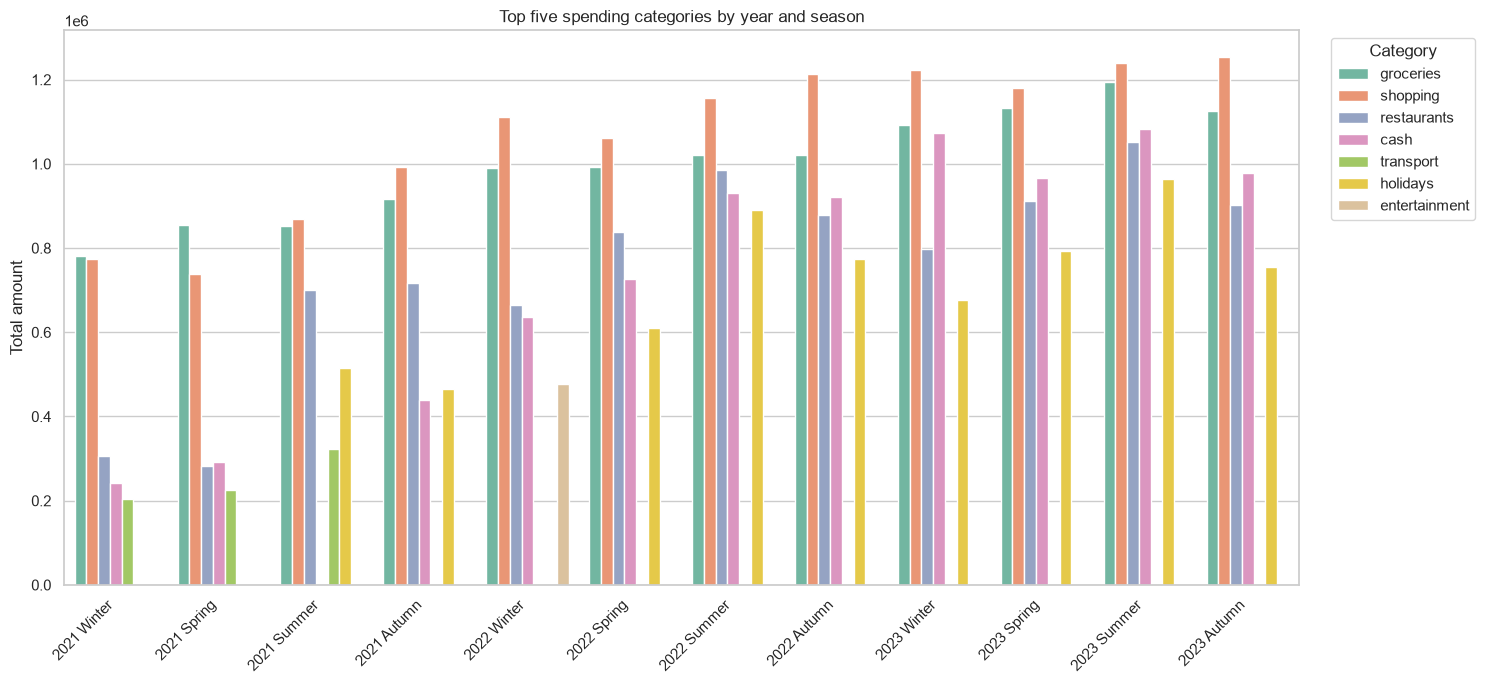

In [8]:
plot_data = top_categories.copy()
plot_data["period"] = (
    plot_data["year"].astype(str) + " " + plot_data["season"].astype(str)
)
period_order = (
    plot_data[["year", "season", "period"]]
    .drop_duplicates()
    .sort_values(["year", "season"])["period"]
    .tolist()
)

plt.figure(figsize=(15, 7))
sns.barplot(
    data=plot_data,
    x="period",
    y="total_amount",
    hue="category",
    order=period_order
)
plt.title("Top five spending categories by year and season")
plt.xlabel("")
plt.ylabel("Total amount")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

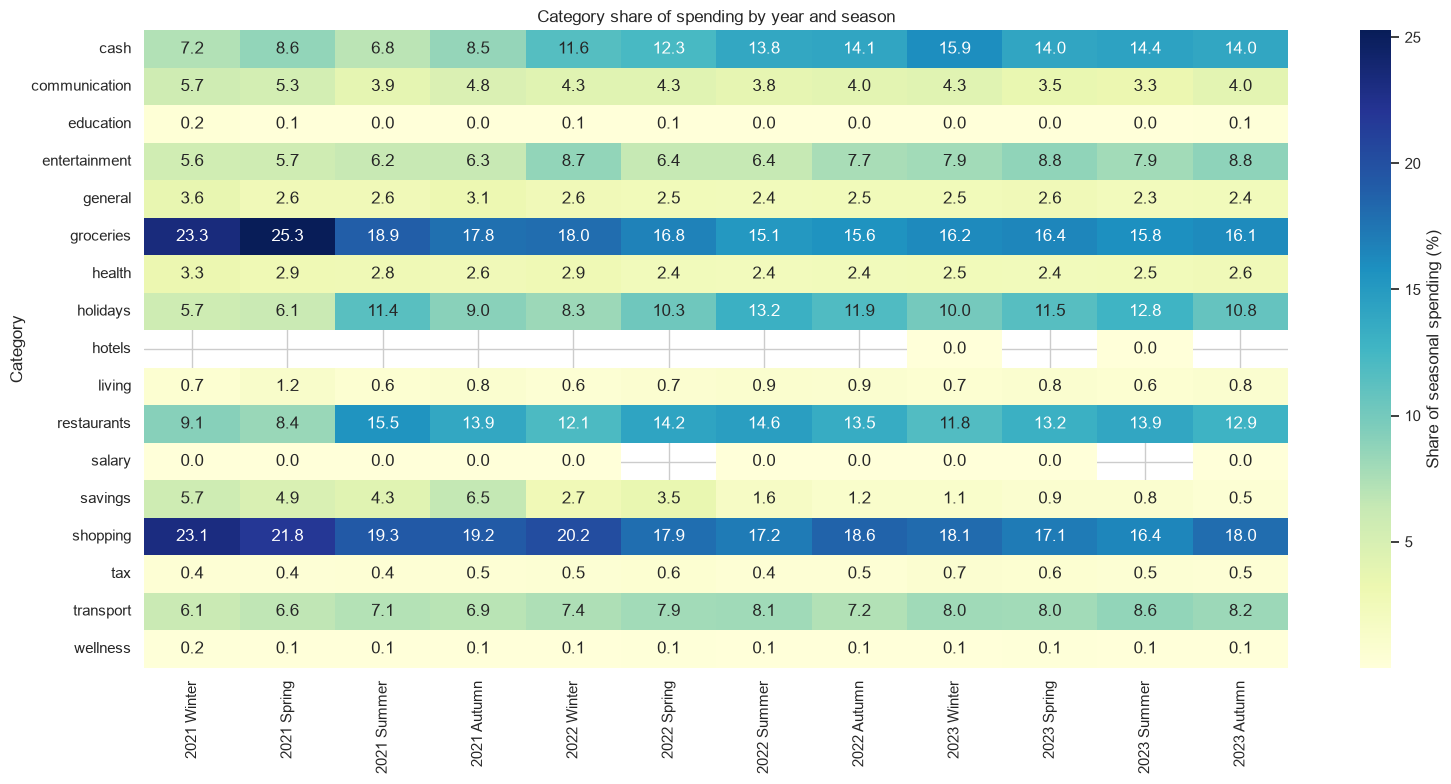

In [9]:
share_heatmap = seasonal_category.pivot_table(
    index="category",
    columns=["year", "season"],
    values="spending_share",
    aggfunc="sum",
    observed=True
)

share_heatmap.columns = [f"{year} {season}" for year, season in share_heatmap.columns]
share_heatmap = share_heatmap.loc[:, period_order]

plt.figure(figsize=(16, 8))
sns.heatmap(
    share_heatmap * 100,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Share of seasonal spending (%)"}
)
plt.title("Category share of spending by year and season")
plt.xlabel("")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## Counterpart and channel analysis

The second dataset can show which counterparts contribute most to each category and whether seasonal spending is mainly in-store or online.

In [4]:
counterpart_seasonal = (
    sow_counterpart
    .groupby(
        ["year", "season", "category", "top_counterpart"],
        observed=True,
        as_index=False
    )
    .agg(
        total_amount=("total_amount", "sum"),
        n_transactions=("n_transasctions", "sum")
    )
)

counterpart_seasonal["rank_in_category"] = (
    counterpart_seasonal
    .groupby(["year", "season", "category"], observed=True)["total_amount"]
    .rank(method="first", ascending=False)
)

top_counterparts = counterpart_seasonal[
    counterpart_seasonal["rank_in_category"] <= 3
].sort_values(
    ["year", "season", "category", "rank_in_category"]
)

display(top_counterparts.head(20).round(2))

,year,season,category,top_counterpart,total_amount,n_transactions,rank_in_category
2,2021,Winter,cash,other,"153,714.57",696,1.00
0,2021,Winter,cash,binance,"27,813.14",126,2.00
3,2021,Winter,cash,postfinance,"13,203.84",61,3.00
13,2021,Winter,communication,other,"89,482.38",1948,1.00
9,2021,Winter,communication,apple,"59,569.20",1880,2.00
14,2021,Winter,communication,paypal,"10,112.60",321,3.00
19,2021,Winter,education,other,"7,600.96",12,1.00
26,2021,Winter,entertainment,other,"109,338.51",1594,1.00
30,2021,Winter,entertainment,swiss casinos,"19,534.70",217,2.00
21,2021,Winter,entertainment,interwetten,"15,004.00",76,3.00


### Top counterpart chart

Select a year and season below to compare the highest-spending counterparts across categories.

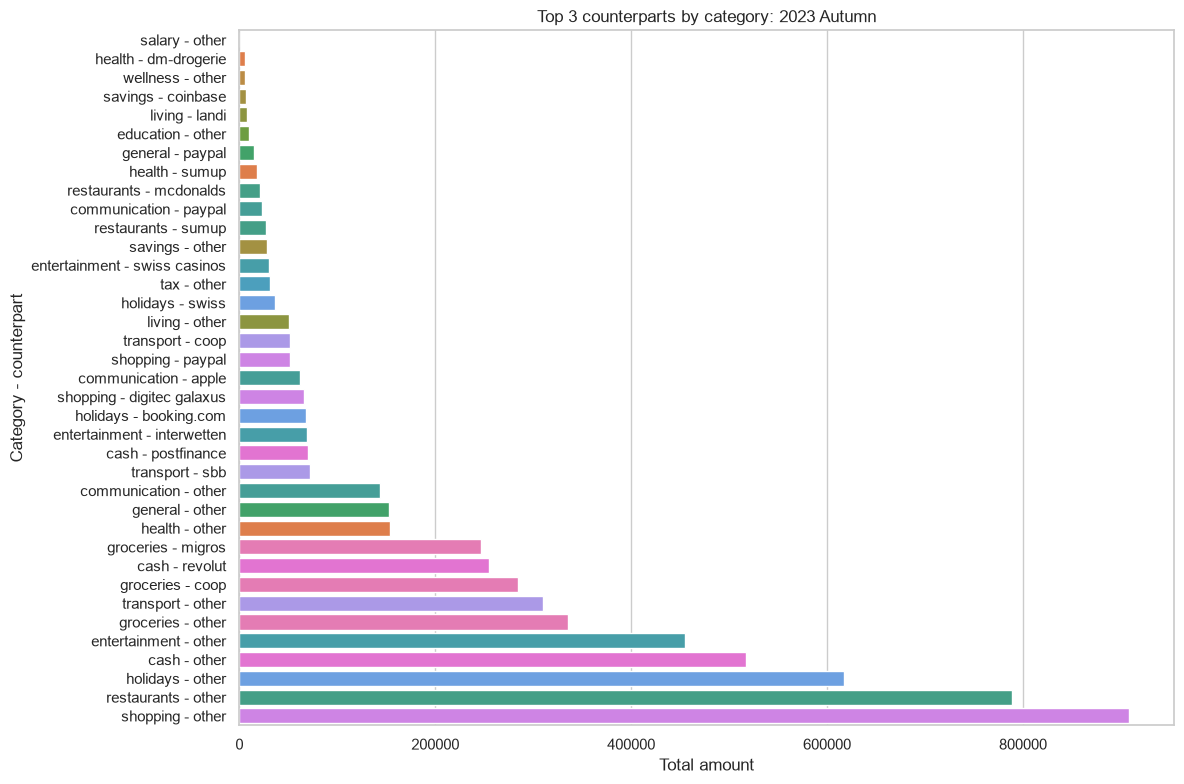

,category,top_counterpart,total_amount,n_transactions,rank_in_category
1502,salary,other,20.00,1,1.00
1480,health,dm-drogerie,"5,616.15",153,3.00
1547,wellness,other,"5,956.65",53,1.00
1503,savings,coinbase,"7,087.15",105,2.00
1487,living,landi,"7,632.70",171,2.00
1440,education,other,"9,737.14",25,1.00
1454,general,paypal,"15,284.13",221,2.00
1482,health,sumup,"18,203.10",164,2.00
1492,restaurants,mcdonalds,"21,441.97",1250,3.00
1434,communication,paypal,"22,663.61",550,3.00


In [5]:
selected_year = 2023
selected_season = "Autumn"
top_n = 3

selected_counterparts = top_counterparts[
    (top_counterparts["year"] == selected_year)
    & (top_counterparts["season"] == selected_season)
    & (top_counterparts["rank_in_category"] <= top_n)
].copy()

selected_counterparts["label"] = (
    selected_counterparts["category"].astype(str)
    + " - "
    + selected_counterparts["top_counterpart"].astype(str)
)
selected_counterparts = selected_counterparts.sort_values("total_amount")

plt.figure(figsize=(12, 8))
sns.barplot(
    data=selected_counterparts,
    x="total_amount",
    y="label",
    hue="category",
    dodge=False,
    legend=False
)
plt.title(f"Top {top_n} counterparts by category: {selected_year} {selected_season}")
plt.xlabel("Total amount")
plt.ylabel("Category - counterpart")
plt.tight_layout()
plt.show()

display(
    selected_counterparts[
        ["category", "top_counterpart", "total_amount", "n_transactions", "rank_in_category"]
    ].round(2)
)